**Data Wrangling Skill Part 1**

Description: Four main concepts are covered in this lab: 
1) missing data; 2) outliers; 3) skill in transformation~ sub-setting & reshaping; 4) date and time. 

**Missing Data**

1.	Let us use back the data that you have downloaded in lab 5, i.e. breast-cancer-wisconsin data. This data set contains the following attributes: 

    Sample code number id number
    Clump Thickness 1 - 10
    Uniformity of Cell Size 1 - 10
    Uniformity of Cell Shape 1 - 10
    Marginal Adhesion 1 - 10
    Single Epithelial Cell Size 1 - 10
    Bare Nuclei 1 - 10
    Bland Chromatin 1 - 10
    Normal Nucleoli 1 - 10
    Mitoses 1 - 10
    Class: (2 for benign, 4 for malignant)
    This datahasg missing values which are marked as "?"

Go to https://archive.ics.uci.edu/ml/datasets/breast+cancer+wisconsin+(original) to read the description about the data. You will find out that this dataset contains missing values. Now, let us import the data to Pandas data frame and name the columns by using the following command. 


In [1]:
import pandas as pd
import numpy as np
#since the original data has no header, we just add in using data.columns
data = pd.read_csv('breast-cancer-wisconsin.data', sep=",", header=None)
data.columns=["ID","Clump_Thickness","Uniformity_CellSize","Uniformity_CellShape","Marginal_Adhesion","Single_Epithelial","Bare_Nuclei","Bland_Chromatin", "Normal_Nucleoli", "Mitoses","Classes"]
print (data.head()) #display the first few rows of data
data.describe


        ID  Clump_Thickness  Uniformity_CellSize  Uniformity_CellShape  \
0  1000025                5                    1                     1   
1  1002945                5                    4                     4   
2  1015425                3                    1                     1   
3  1016277                6                    8                     8   
4  1017023                4                    1                     1   

   Marginal_Adhesion  Single_Epithelial Bare_Nuclei  Bland_Chromatin  \
0                  1                  2           1                3   
1                  5                  7          10                3   
2                  1                  2           2                3   
3                  1                  3           4                3   
4                  3                  2           1                3   

   Normal_Nucleoli  Mitoses  Classes  
0                1        1        2  
1                2        1        2  
2    

<bound method NDFrame.describe of           ID  Clump_Thickness  Uniformity_CellSize  Uniformity_CellShape  \
0    1000025                5                    1                     1   
1    1002945                5                    4                     4   
2    1015425                3                    1                     1   
3    1016277                6                    8                     8   
4    1017023                4                    1                     1   
..       ...              ...                  ...                   ...   
694   776715                3                    1                     1   
695   841769                2                    1                     1   
696   888820                5                   10                    10   
697   897471                4                    8                     6   
698   897471                4                    8                     8   

     Marginal_Adhesion  Single_Epithelial Bare_Nuclei

**Identify the Missing Data**

In the real world, data scientist will explore the data to define any missing data. Sometimes missing data may contain some weird characters, sometimes it is blank, or null. In the data description, we know that the missing data for breast cancer is recorded as "?". If you try to search and explore the missing values, you find nothing. 


In [3]:
import pandas as pd
import numpy as np
#since the original data has no header, we just add in using data.columns
data = pd.read_csv('breast-cancer-wisconsin.data', sep=",", header=None)
data.columns=["ID","Clump_Thickness","Uniformity_CellSize","Uniformity_CellShape","Marginal_Adhesion","Single_Epithelial","Bare_Nuclei","Bland_Chromatin", "Normal_Nucleoli", "Mitoses","Classes"]

#print (data.head()) #display the first few rows of data
#data.describe

#before replacing the missing data
print(data.isnull().sum())

#replace the missing data
#observe that the missing data is contains in Bare_Nuclei
data = data.replace('?',np.NaN)

print('\nNumber of instances = %d' % (data.shape[0]))
print('Number of attributes = %d' % (data.shape[1]))

print('Number of missing values:')
for col in data.columns:
    print('\t%s: %d' % (col,data[col].isna().sum()))

#Sample solution: Bare_Nuclei is having the missing 



ID                      0
Clump_Thickness         0
Uniformity_CellSize     0
Uniformity_CellShape    0
Marginal_Adhesion       0
Single_Epithelial       0
Bare_Nuclei             0
Bland_Chromatin         0
Normal_Nucleoli         0
Mitoses                 0
Classes                 0
dtype: int64

Number of instances = 699
Number of attributes = 11
Number of missing values:
	ID: 0
	Clump_Thickness: 0
	Uniformity_CellSize: 0
	Uniformity_CellShape: 0
	Marginal_Adhesion: 0
	Single_Epithelial: 0
	Bare_Nuclei: 16
	Bland_Chromatin: 0
	Normal_Nucleoli: 0
	Mitoses: 0
	Classes: 0


**Handling Missing Data**

In this sample code here, two imputation techniques are applied:

1.	To fill up missing values with **median**.
2.	Impute by using **linear interpolation**
    We do not set inplace = True, so that it does not rewrite the original data.

In [5]:
import pandas as pd
import numpy as np
#since the original data has no header, we just add in using data.columns
data = pd.read_csv('breast-cancer-wisconsin.data', sep=",", header=None)
data.columns=["ID","Clump_Thickness","Uniformity_CellSize","Uniformity_CellShape","Marginal_Adhesion","Single_Epithelial","Bare_Nuclei","Bland_Chromatin", "Normal_Nucleoli", "Mitoses","Classes"]

#print (data.head()) #display the first few rows of data
#data.describe

#before replacing the missing data
print(data.isnull().sum())

ID                      0
Clump_Thickness         0
Uniformity_CellSize     0
Uniformity_CellShape    0
Marginal_Adhesion       0
Single_Epithelial       0
Bare_Nuclei             0
Bland_Chromatin         0
Normal_Nucleoli         0
Mitoses                 0
Classes                 0
dtype: int64


In [8]:
#replace the missing data
#observe that the missing data is contains in Bare_Nuclei
data['Bare_Nuclei'] = pd.to_numeric(data['Bare_Nuclei'], errors='coerce')

data = data.replace('?',np.NaN)

print('\nNumber of instances = %d' % (data.shape[0]))
print('Number of attributes = %d' % (data.shape[1]))

print('Number of missing values:')
for col in data.columns:
    print('\t%s: %d' % (col,data[col].isna().sum()))


#Sample solution: Bare_Nuclei is having the missing 

data_impMedian = data.Bare_Nuclei.fillna(data.Bare_Nuclei.median())#, inplace = True)
data_impMedian.isnull().sum() #now no more missing values for column Bare_Nuclei

data_impInter = data.Bare_Nuclei.interpolate(method='linear', direction = 'forward') 
data_impInter.isna().any()



Number of instances = 699
Number of attributes = 11
Number of missing values:
	ID: 0
	Clump_Thickness: 0
	Uniformity_CellSize: 0
	Uniformity_CellShape: 0
	Marginal_Adhesion: 0
	Single_Epithelial: 0
	Bare_Nuclei: 16
	Bland_Chromatin: 0
	Normal_Nucleoli: 0
	Mitoses: 0
	Classes: 0


False

**Dealing with Missing Data**

In this exercise, you need to download Estate.csv and import it into Pandas data frame. This is a small data set which contains only 10 rows. There are three different types of missing data: standard missing data (in column ST_NUM), non standard missing data (in NUM_BEDROOMS), and unexpected missing values (in OWN_OCCUPIED). 

Now, complete the following tasks by using appropriate python code.

1) Import the relevant libraries, read the data into Pandas data frame and look at the first few rows.

2) Dealing with the standard missing data - check the number of missing values of each column.

3) Check the value of NUM_BEDROOM. Note that, these columns contain non-standard missing values as well. Change all the non-standard missing values to NaN. After that, check the value of NUM_BEDROOMS.

4) Assume that you found OWN_OCCUPIED is having unexpected error. Check the values of this column and observe that it contains data with different data type. Then perform the steps below to change the values that are not the similar type into an integer, and then to np.nan.

**Steps:** 
1. Loop through the OWN_OCCUPIED column 
2. Try and turn the entry into an integer 
3. If the entry can be changed into an integer, enter a missing value 
4. If the number can’t be an integer, we know it’s a string, so keep going without doing anything 


In [9]:
#Task 1
#import libraries
import pandas as pd
import numpy as np

#store data into pandas data frame
data1 = pd.read_csv("Estate.csv")

# Look at the first few rows
print (data1.head()) 
print()

           PID  ST_NUM    ST_NAME OWN_OCCUPIED NUM_BEDROOMS NUM_BATH SQ_FT
0  100001000.0   104.0     PUTNAM            Y            3        1  1000
1  100002000.0   197.0  LEXINGTON            N            3      1.5    --
2  100003000.0     NaN  LEXINGTON            N          NaN        1   850
3  100004000.0   201.0   BERKELEY           12            1      NaN   700
4          NaN   203.0   BERKELEY            Y            3        2  1600



In [10]:
#Task 2: Try and turn the entry into an integer 
print(data1.isnull().sum())

PID             1
ST_NUM          2
ST_NAME         0
OWN_OCCUPIED    1
NUM_BEDROOMS    2
NUM_BATH        1
SQ_FT           1
dtype: int64


In [11]:
# Task 3: If the entry can be changed into an integer, enter a missing value 
print(data1["NUM_BEDROOMS"])
print()

# Making a list of missing value types
missing_values = ["n/a", "na", "--"]
data1 = pd.read_csv("Estate.csv", na_values=missing_values)
print(data1["NUM_BEDROOMS"])
print()

# Task 4: If the number can’t be an integer, we know it’s a string, so keep going without doing anything
# Detecting numbers in the 'OWN_OCCUPIED' column
count = 0
for row in data1["OWN_OCCUPIED"]:
    try:
        int(row)
        data1.loc[count, "OWN_OCCUPIED"] = np.nan
    except ValueError:
        pass
    count += 1

# Replace missing values in 'ST_NUM' with a number
data1["ST_NUM"].fillna(125, inplace=True)

# Location-based replacement
data1.loc[2, "ST_NUM"] = 125
print(data1["ST_NUM"])
print()

# Replace missing values in 'NUM_BEDROOMS' using the median
median = data1["NUM_BEDROOMS"].median()
print("Median is", median)
print()
data1["NUM_BEDROOMS"].fillna(median, inplace=True)
print(data1["NUM_BEDROOMS"])


0      3
1      3
2    NaN
3      1
4      3
5    NaN
6      2
7      1
8     na
Name: NUM_BEDROOMS, dtype: object

0    3.0
1    3.0
2    NaN
3    1.0
4    3.0
5    NaN
6    2.0
7    1.0
8    NaN
Name: NUM_BEDROOMS, dtype: float64

0    104.0
1    197.0
2    125.0
3    201.0
4    203.0
5    207.0
6    125.0
7    213.0
8    215.0
Name: ST_NUM, dtype: float64

Median is 2.5

0    3.0
1    3.0
2    2.5
3    1.0
4    3.0
5    2.5
6    2.0
7    1.0
8    2.5
Name: NUM_BEDROOMS, dtype: float64


C:\Users\pangt\AppData\Local\Temp\ipykernel_60148\341057070.py:23: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data1["ST_NUM"].fillna(125, inplace=True)
C:\Users\pangt\AppData\Local\Temp\ipykernel_60148\341057070.py:34: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, w

**Outliers**

In this section, you will learn about the skill to deal with outliers. 

**Steps:** 
1. Import all the necessary modules include Pandas, Numpy and as visualization is useful for outliers, so seaborn and matplotlib are imported too. 

2. We will use a dataset, i.e. California Housing from scikit learn module and zscore from scipy to explore outliers.

3. Download the data and assign to Data1. 

4. Check the features name. 

5.	Data1 is not a Pandas data frame. Now we transform Data1 to Pandas data frame.

6.	Look at the first feature, MedInc, i.e. median income for households by using box plot. Box plot explores the outliers of a single feature. 

7.	Another method to visualize outliers is scatter plot. In python,  alpha allow us to set the transparency degree of the plot. 

8.	Visualize the data through histogram is flexible as you can explore one single feature at one time or you can observe all features at the same time. First, we check the histogram of MedInc. Then, we observe the histograms of all features.  

9.	We can use z-score to explore and identify outliers. Add one additional column to store the value of z-score.

10.	Commonly, values more than/less than (+/-) 3 standard deviation are deemed as outliers. We can choose to remove outliers or restore the data to another data frame.

In [12]:
#Task 1
#import libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


#Task 2
from scipy.stats import zscore
from sklearn.datasets import fetch_california_housing
from math import cos, pi


#Task 3: Download the data and assign to Data1.
Data1 = fetch_california_housing()

#Task 4: Check the features name.
Data1.feature_names

['MedInc',
 'HouseAge',
 'AveRooms',
 'AveBedrms',
 'Population',
 'AveOccup',
 'Latitude',
 'Longitude']

In [13]:
#Task 5: Data1 is not a Pandas data frame. transform Data1 to Pandas data frame.
House = pd.DataFrame(Data1.data, columns=Data1.feature_names)
House.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


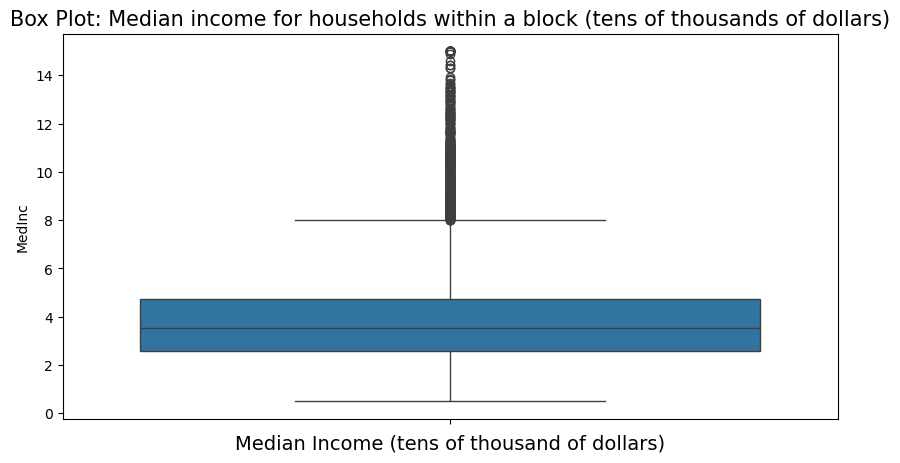

In [14]:
#Task 6: median income for households by using box plot and explores the outliers of a single feature. 
fig = plt.figure(figsize=(10,5))
sns.boxplot(House.MedInc)
plt.title('Box Plot: Median income for households within a block (tens of thousands of dollars)', fontsize=15)
plt.xlabel('Median Income (tens of thousand of dollars)', fontsize=14)
plt.show()

Text(0.5, 1.0, 'Median Income vs Population')

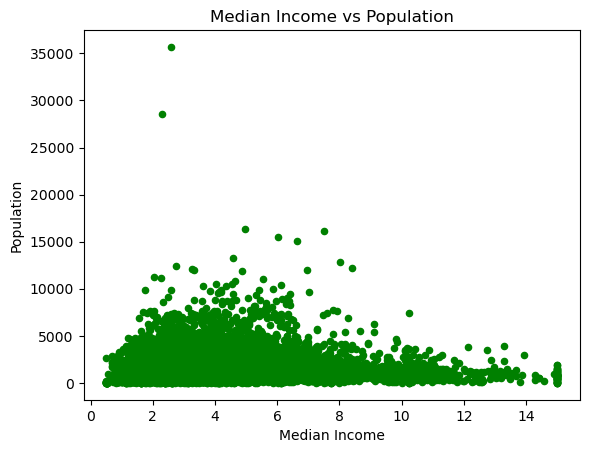

In [15]:
#Task 7
House.plot(kind='scatter', x='MedInc', y='Population', alpha=1, color='green')
plt.xlabel('Median Income')
plt.ylabel('Population')
plt.title('Median Income vs Population')

array([[<Axes: title={'center': 'MedInc'}>,
        <Axes: title={'center': 'HouseAge'}>,
        <Axes: title={'center': 'AveRooms'}>],
       [<Axes: title={'center': 'AveBedrms'}>,
        <Axes: title={'center': 'Population'}>,
        <Axes: title={'center': 'AveOccup'}>],
       [<Axes: title={'center': 'Latitude'}>,
        <Axes: title={'center': 'Longitude'}>, <Axes: >]], dtype=object)

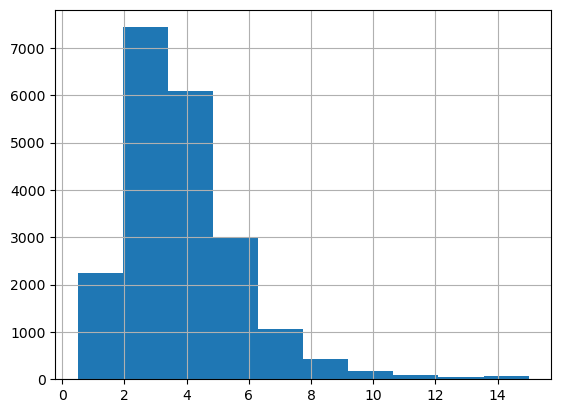

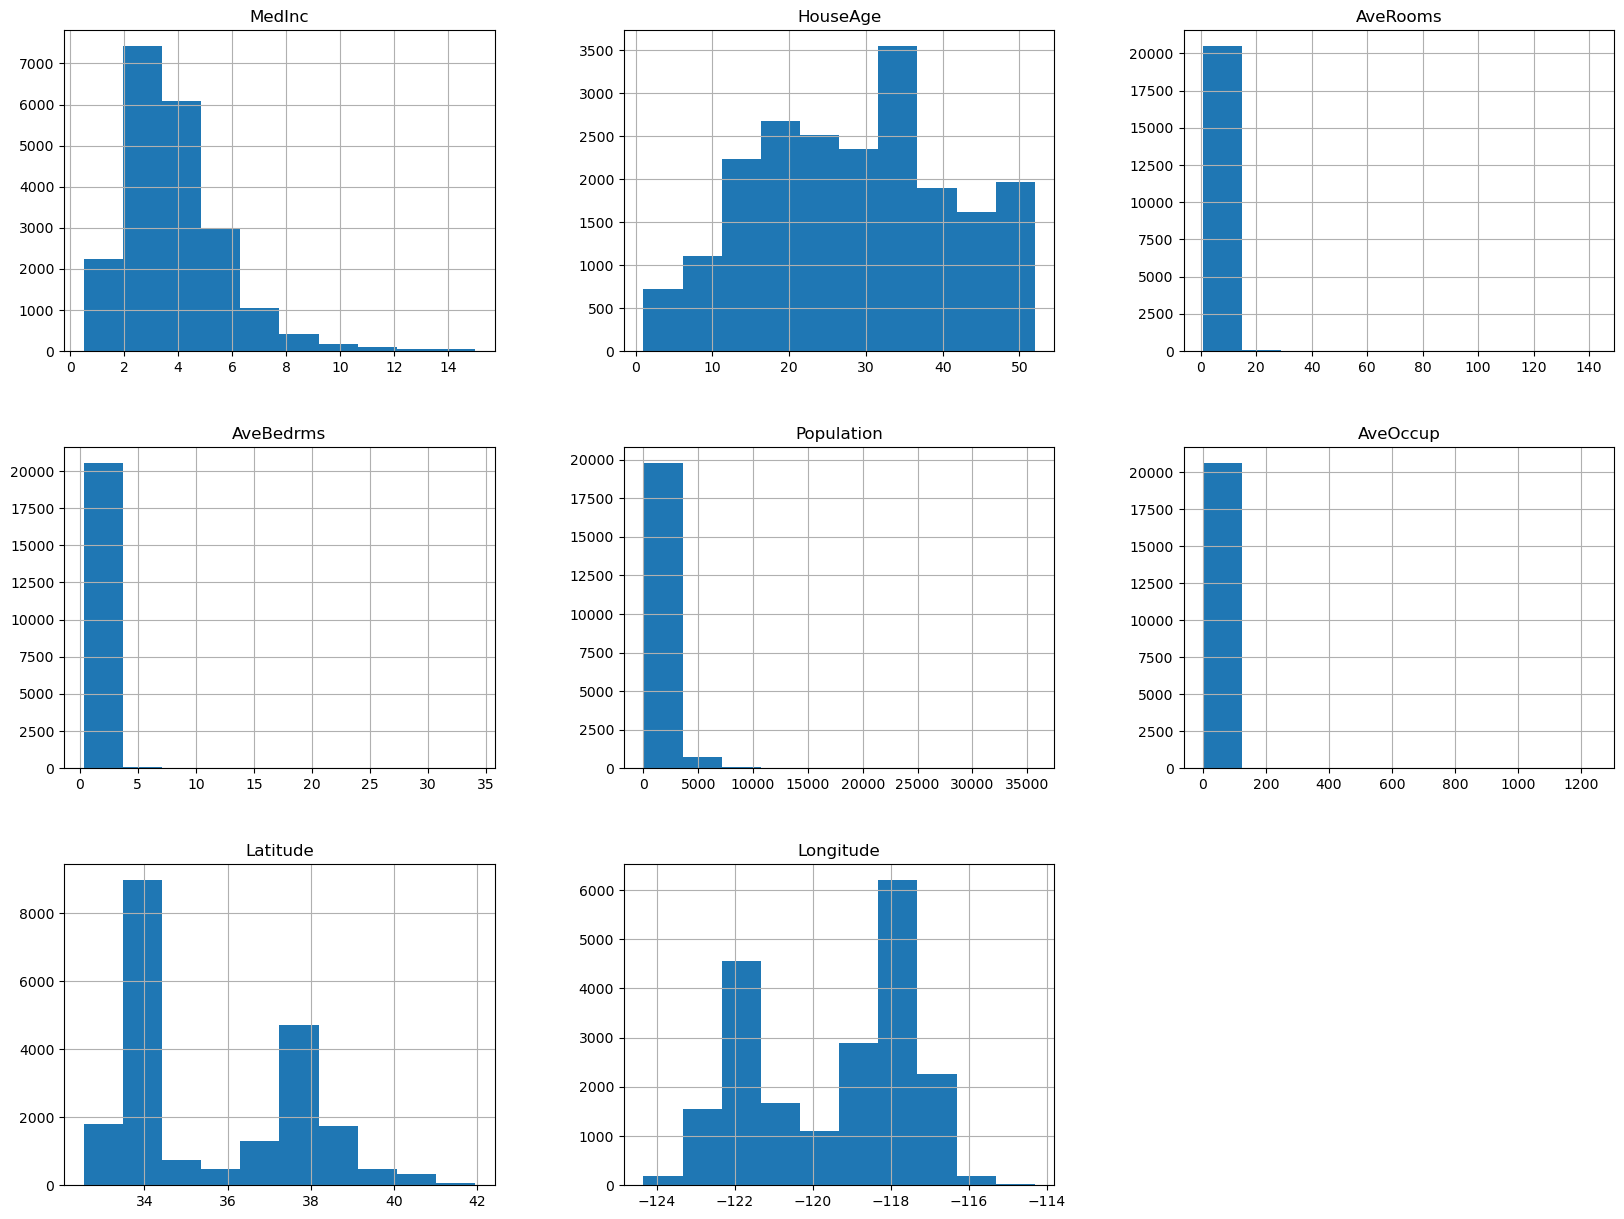

In [16]:
#Task 8
House.MedInc.hist() #single feature
House.hist(figsize = (20,15)) #all features

In [18]:
#Task 9
result = zscore(House.MedInc)
#add result as additional attribute in House
House['resultZ'] = result


#Task 10
#remove outliers and restore data 
House_noOutliers = House[((House['resultZ'] < 3) & (House['resultZ'] > -3))]
display(House_noOutliers)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,resultZ
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,2.344766
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,2.332238
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,1.782699
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,0.932968
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,-0.012881
...,...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,-1.216128
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,-0.691593
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,-1.142593
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,-1.054583


**Exercise 2: Dealing with Outliers**

In this exercise, we will use the Boston housing data. You can download directly from this link here: https://github.com/selva86/datasets/blob/master/BostonHousing.csv as it has been removed from sklearn. This data has no missing values with 506 samples. The attributes information is as below: 

1. CRIM      per capita crime rate by town
2. ZN        proportion of residential land zoned for lots over 25,000 sq.ft.
3. INDUS     proportion of non-retail business acres per town
4. CHAS      Charles River dummy variable (= 1 if tract bounds river; 0 otherwise)
5. NOX       nitric oxides concentration (parts per 10 million)
6. RM        average number of rooms per dwelling
7. AGE       proportion of owner-occupied units built prior to 1940
8. DIS       weighted distances to five Boston employment centres
9. RAD       index of accessibility to radial highways
10. TAX      full-value property-tax rate per $10,000
11. PTRATIO  pupil-teacher ratio by town
12. B        1000(Bk - 0.63)^2 where Bk is the proportion of blacks by town
13. LSTAT    % lower status of the population
14. MEDV     Median value of owner-occupied homes in $1000's
 
 
 **Steps**
 
1. Download Boston housing data from eBwise, load the data and save in a Pandas 
data frame. Remember to import all the necessary files. 

2. Check the features and view the first few rows of the data.

3. Visualize the feature CRIM (per capita crime rate) by using box plot.

4. Check all the features by using histogram.

5. Define the z-score of CRIM. 

6. Remove those data with z-score (+/-) exceeding 3 standard deviation. 
How many samples are removed from the data?  

Answer: 8 samples were removed from the data

In [19]:
#import libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from scipy.stats import zscore
from sklearn.datasets import fetch_california_housing
from math import cos, pi

#Task 1
df = pd.read_csv("BostonHousing.csv")

#Task 2: Check the features and view the first few rows of the data.
print("Task 2")
print(df.head())

Task 2
      crim    zn  indus  chas    nox     rm   age     dis  rad  tax  ptratio  \
0  0.00632  18.0   2.31     0  0.538  6.575  65.2  4.0900    1  296     15.3   
1  0.02731   0.0   7.07     0  0.469  6.421  78.9  4.9671    2  242     17.8   
2  0.02729   0.0   7.07     0  0.469  7.185  61.1  4.9671    2  242     17.8   
3  0.03237   0.0   2.18     0  0.458  6.998  45.8  6.0622    3  222     18.7   
4  0.06905   0.0   2.18     0  0.458  7.147  54.2  6.0622    3  222     18.7   

        b  lstat  medv  
0  396.90   4.98  24.0  
1  396.90   9.14  21.6  
2  392.83   4.03  34.7  
3  394.63   2.94  33.4  
4  396.90   5.33  36.2  


Task 3


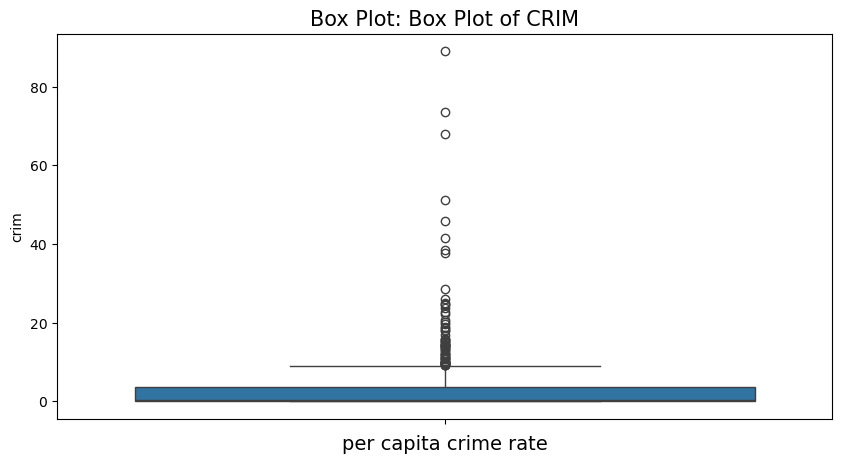

In [20]:
#Task 3: Visualize the feature CRIM (per capita crime rate) by using box plot.
print("Task 3")
fig = plt.figure(figsize=(10,5))
sns.boxplot(df.crim)
plt.title('Box Plot: Box Plot of CRIM', fontsize=15)
plt.xlabel('per capita crime rate', fontsize=14)
plt.show()
print()

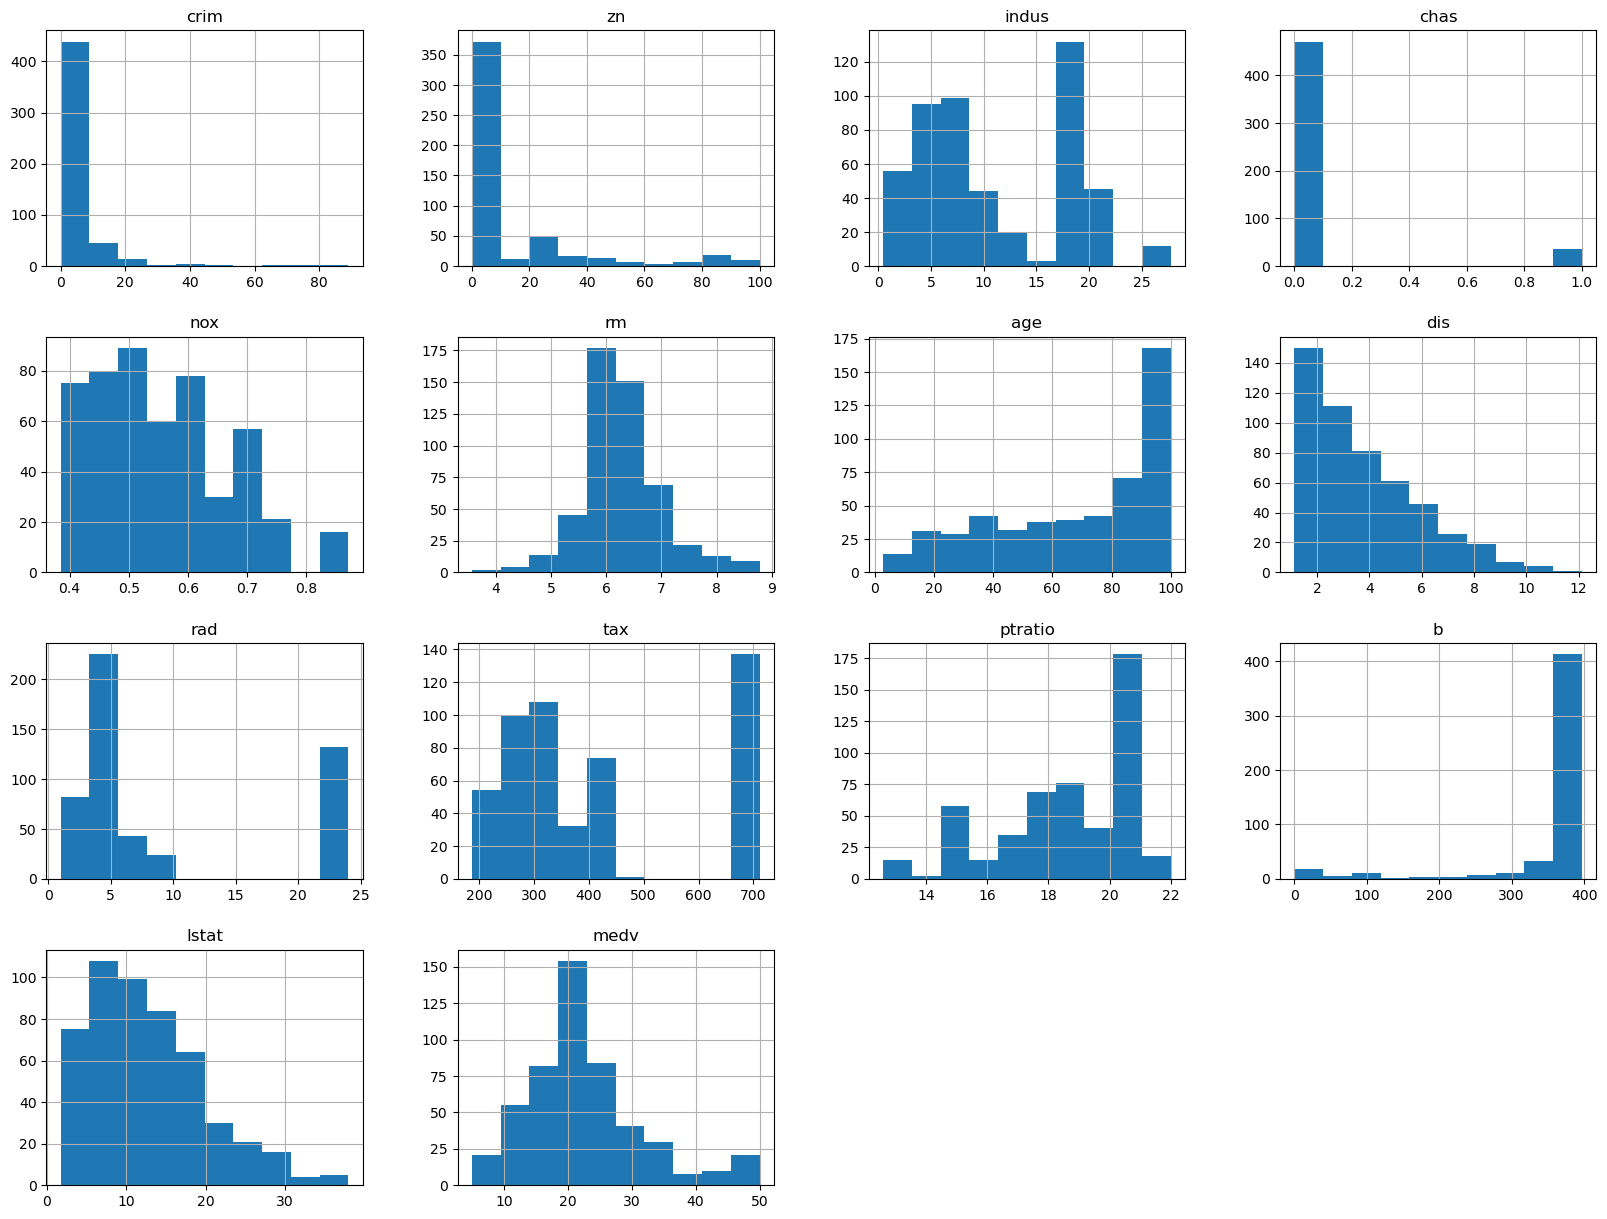

In [21]:
#Task 4: Check all the features by using histogram.
df.hist(figsize=(20,15))
print()

In [24]:
#Task 5: Define the z-score of CRIM.
print("Task 5")
result = zscore(df.crim)
df['resultZ']=result

#Task 6: Remove those data with z-score (+/-) exceeding 3 standard deviation. How many samples are removed from the data?
print("Task 6")
# remove outliers and restore data
boston_df_noOutliers = df[((df['resultZ'] < 3) & (df['resultZ'] > -3))]
display(boston_df_noOutliers)

Task 5
Task 6


,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv,resultZ
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0,-0.419782
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6,-0.417339
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7,-0.417342
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4,-0.416750
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2,-0.412482
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0,0.573,6.593,69.1,2.4786,1,273,21.0,391.99,9.67,22.4,-0.413229
502,0.04527,0.0,11.93,0,0.573,6.120,76.7,2.2875,1,273,21.0,396.90,9.08,20.6,-0.415249
503,0.06076,0.0,11.93,0,0.573,6.976,91.0,2.1675,1,273,21.0,396.90,5.64,23.9,-0.413447
504,0.10959,0.0,11.93,0,0.573,6.794,89.3,2.3889,1,273,21.0,393.45,6.48,22.0,-0.407764


**Subsetting**

In this section, download the data: **Cell Phone Total.xlsx** from eBwise and store in the active directory of Jupyter notebook. 
 
 
 **Steps**
 
1. Read in the excel file and store in Pandas data frame.

2. This data contains a lot of missing values. 
We can use precision method to remove columns that have 80% of missing values. 

3. Check the duplicated records. 

4. Print out all the columns. Suppose the 1st column is not treated as column. 
Rename the 1st columns as ‘Country’. 

5. Set ‘Country’ as index. 

6. Subsetting by columns: now select the subset of United Kingdom and save in data_sub1.
How many samples are removed from the data?  

7. Now, extract Northen European countries, this includes: United Kindom, Sweden, Denmark,
Finland, Norway, Ireland, Lithuania, Latvia, Estonia, and Iceland. Save these values into 
data_sub1 and print out the values.

Note: if you putting a wrong brackets for .loc function, you may get an error as 
Too Many Indexers.

8. Continue to extract only data from 2000 to 2011 from data_sub1.

9. We can sort the values according to a specific column. 

10. Now subset the data to only Finland, Norway, and Ireland with the cellular 
subscription for year 2003 and 2005.Then filter the data where the subscription amount 
of year 2005 is less than 4000000. Store this subset and replace data_sub2.


In [25]:
#import libraries
import pandas as pd
import numpy as np

#Task 1
print("Task 1")
data = pd.read_excel ('cell phone total.xlsx', header=[0]) 
#change the drive link accordingly
#r (raw string) will turn off the 8 character Unicode escape which fail (avoid parsing error)
print(data.head())
print()

Task 1
  Mobile cellular subscriptions, total number  1965  1966  1967  1968  1969  \
0                                    Abkhazia   NaN   NaN   NaN   NaN   NaN   
1                                 Afghanistan   0.0   NaN   NaN   NaN   NaN   
2                       Akrotiri and Dhekelia   NaN   NaN   NaN   NaN   NaN   
3                                     Albania   0.0   NaN   NaN   NaN   NaN   
4                                     Algeria   0.0   NaN   NaN   NaN   NaN   

   1970  1971  1972  1973  ...      2002       2003       2004        2005  \
0   NaN   NaN   NaN   NaN  ...       NaN        NaN        NaN         NaN   
1   0.0   NaN   NaN   NaN  ...   25000.0   200000.0   600000.0   1200000.0   
2   NaN   NaN   NaN   NaN  ...       NaN        NaN        NaN         NaN   
3   0.0   NaN   NaN   NaN  ...  851000.0  1100000.0  1259590.0   1530244.0   
4   0.0   NaN   NaN   NaN  ...  450244.0  1446927.0  4882414.0  13661355.0   

         2006        2007        2008        2009

In [27]:
#Task 2: This data contains a lot of missing values. We can use precision method to remove columns that have 80% of missing values.
print("Task 2")
threshold = data.isnull().sum(axis=1)/(len(data.columns)-1) 
#exclude the 1st column which is the name of countries.
remove_row = threshold[threshold>0.8].index
data.drop(remove_row, axis=0, inplace = True)
print(data.head()) 
print()
#check to make sure it moves only those with missing values >80%.
print(len(data))
print()

Task 2
  Mobile cellular subscriptions, total number  1965  1966  1967  1968  1969  \
1                                 Afghanistan   0.0   NaN   NaN   NaN   NaN   
3                                     Albania   0.0   NaN   NaN   NaN   NaN   
4                                     Algeria   0.0   NaN   NaN   NaN   NaN   
5                              American Samoa   0.0   NaN   NaN   NaN   NaN   
6                                     Andorra   0.0   NaN   NaN   NaN   NaN   

   1970  1971  1972  1973  ...      2002       2003       2004        2005  \
1   0.0   NaN   NaN   NaN  ...   25000.0   200000.0   600000.0   1200000.0   
3   0.0   NaN   NaN   NaN  ...  851000.0  1100000.0  1259590.0   1530244.0   
4   0.0   NaN   NaN   NaN  ...  450244.0  1446927.0  4882414.0  13661355.0   
5   0.0   NaN   NaN   NaN  ...    2036.0     2100.0     2250.0         NaN   
6   0.0   NaN   NaN   NaN  ...   32790.0    51893.0    58366.0     64560.0   

         2006        2007        2008        2009

In [28]:
#Task 3: Check the duplicated records.
print("Task 3")
data.duplicated()
print(data.head())
print()

Task 3
  Mobile cellular subscriptions, total number  1965  1966  1967  1968  1969  \
1                                 Afghanistan   0.0   NaN   NaN   NaN   NaN   
3                                     Albania   0.0   NaN   NaN   NaN   NaN   
4                                     Algeria   0.0   NaN   NaN   NaN   NaN   
5                              American Samoa   0.0   NaN   NaN   NaN   NaN   
6                                     Andorra   0.0   NaN   NaN   NaN   NaN   

   1970  1971  1972  1973  ...      2002       2003       2004        2005  \
1   0.0   NaN   NaN   NaN  ...   25000.0   200000.0   600000.0   1200000.0   
3   0.0   NaN   NaN   NaN  ...  851000.0  1100000.0  1259590.0   1530244.0   
4   0.0   NaN   NaN   NaN  ...  450244.0  1446927.0  4882414.0  13661355.0   
5   0.0   NaN   NaN   NaN  ...    2036.0     2100.0     2250.0         NaN   
6   0.0   NaN   NaN   NaN  ...   32790.0    51893.0    58366.0     64560.0   

         2006        2007        2008        2009

In [30]:
#Task 4: Print out all the columns. Suppose the 1st column is not treated as column. Rename the 1st columns as ‘Country’.
print("Task 4")
print(data.columns)
data.rename(columns={'Mobile cellular subscriptions, total number':'Country'}, inplace = True)
print(data.head())
print()

Task 4
Index(['Country', '1965', '1966', '1967', '1968', '1969', '1970', '1971',
       '1972', '1973', '1974', '1975', '1976', '1977', '1978', '1979', '1980',
       '1981', '1982', '1983', '1984', '1985', '1986', '1987', '1988', '1989',
       '1990', '1991', '1992', '1993', '1994', '1995', '1996', '1997', '1998',
       '1999', '2000', '2001', '2002', '2003', '2004', '2005', '2006', '2007',
       '2008', '2009', '2010', '2011'],
      dtype='object')
          Country  1965  1966  1967  1968  1969  1970  1971  1972  1973  ...  \
1     Afghanistan   0.0   NaN   NaN   NaN   NaN   0.0   NaN   NaN   NaN  ...   
3         Albania   0.0   NaN   NaN   NaN   NaN   0.0   NaN   NaN   NaN  ...   
4         Algeria   0.0   NaN   NaN   NaN   NaN   0.0   NaN   NaN   NaN  ...   
5  American Samoa   0.0   NaN   NaN   NaN   NaN   0.0   NaN   NaN   NaN  ...   
6         Andorra   0.0   NaN   NaN   NaN   NaN   0.0   NaN   NaN   NaN  ...   

       2002       2003       2004        2005        2006   

In [31]:
#Task 5: Set ‘Country’ as index.
print("Task 5")
data.set_index("Country", inplace = True)
print(data.head())
print()

Task 5
                1965  1966  1967  1968  1969  1970  1971  1972  1973  1974  \
Country                                                                      
Afghanistan      0.0   NaN   NaN   NaN   NaN   0.0   NaN   NaN   NaN   NaN   
Albania          0.0   NaN   NaN   NaN   NaN   0.0   NaN   NaN   NaN   NaN   
Algeria          0.0   NaN   NaN   NaN   NaN   0.0   NaN   NaN   NaN   NaN   
American Samoa   0.0   NaN   NaN   NaN   NaN   0.0   NaN   NaN   NaN   NaN   
Andorra          0.0   NaN   NaN   NaN   NaN   0.0   NaN   NaN   NaN   NaN   

                ...      2002       2003       2004        2005        2006  \
Country         ...                                                           
Afghanistan     ...   25000.0   200000.0   600000.0   1200000.0   2520366.0   
Albania         ...  851000.0  1100000.0  1259590.0   1530244.0   1909885.0   
Algeria         ...  450244.0  1446927.0  4882414.0  13661355.0  20997954.0   
American Samoa  ...    2036.0     2100.0     2250.0

In [32]:
#Task 6: Subsetting by columns: now select the subset of United Kingdom and save in data_sub1. How many samples are removed from the data?
print("Task 6")
data_sub1 = data.loc["United Kingdom"]
print(data_sub1)
print()

Task 6
1965           0.0
1966           NaN
1967           NaN
1968           NaN
1969           NaN
1970           0.0
1971           NaN
1972           NaN
1973           NaN
1974           NaN
1975           0.0
1976           0.0
1977           0.0
1978           0.0
1979           0.0
1980           0.0
1981           0.0
1982           0.0
1983           0.0
1984           0.0
1985       50000.0
1986      130000.0
1987      290000.0
1988      560000.0
1989      975000.0
1990     1114000.0
1991     1260000.0
1992     1507000.0
1993     2268000.0
1994     3940000.0
1995     5735785.0
1996     7248355.0
1997     8841000.0
1998    14878000.0
1999    27185000.0
2000    43452000.0
2001    46283000.0
2002    49228000.0
2003    54256221.0
2004    59687915.0
2005    65471665.0
2006    70077926.0
2007    73836210.0
2008    76735443.0
2009    80255445.0
2010    81115492.0
2011    81612000.0
Name: United Kingdom, dtype: float64



In [33]:
#Task 7: extract Northen European countries, Save these values into data_sub1 and print out the values.
print("Task 7")
#obtain index of all the Northen European countries
data_sub1 = data.loc[["United Kingdom","Sweden", "Denmark", "Finland", "Norway","Ireland", 
                      "Lithuania", "Latvia", "Estonia","Iceland"]]
print(data_sub1)
type(data_sub1) #check the type of data_sub1, it is a data frame
print()

Task 7
                1965  1966  1967  1968  1969  1970  1971  1972  1973  1974  \
Country                                                                      
United Kingdom   0.0   NaN   NaN   NaN   NaN   0.0   NaN   NaN   NaN   NaN   
Sweden           0.0   NaN   NaN   NaN   NaN   0.0   NaN   NaN   NaN   NaN   
Denmark          0.0   NaN   NaN   NaN   NaN   0.0   NaN   NaN   NaN   NaN   
Finland          0.0   NaN   NaN   NaN   NaN   0.0   NaN   NaN   NaN   NaN   
Norway           0.0   NaN   NaN   NaN   NaN   0.0   NaN   NaN   NaN   NaN   
Ireland          0.0   NaN   NaN   NaN   NaN   0.0   NaN   NaN   NaN   NaN   
Lithuania        0.0   NaN   NaN   NaN   NaN   0.0   NaN   NaN   NaN   NaN   
Latvia           0.0   NaN   NaN   NaN   NaN   0.0   NaN   NaN   NaN   NaN   
Estonia          0.0   NaN   NaN   NaN   NaN   0.0   NaN   NaN   NaN   NaN   
Iceland          0.0   NaN   NaN   NaN   NaN   0.0   NaN   NaN   NaN   NaN   

                ...        2002        2003        2004 

In [34]:
#Task 8: Continue to extract only data from 2000 to 2011 from data_sub1
print("Task 8")
data1 = data_sub1.loc[:, '2000':'2011']
print(data1)
print()

Task 8
                      2000        2001        2002        2003        2004  \
Country                                                                      
United Kingdom  43452000.0  46283000.0  49228000.0  54256221.0  59687915.0   
Sweden           6372300.0   7178000.0   7949000.0   8801000.0   8785000.0   
Denmark          3363552.0   3960165.0   4477752.0   4767100.0   5166912.0   
Finland          3728625.0   4175587.0   4516772.0   4747126.0   4988000.0   
Norway           3224000.0   3593000.0   3790000.0   4060829.0   4524750.0   
Ireland          2461000.0   2970000.0   3000000.0   3500000.0   3860000.0   
Lithuania         524000.0   1017999.0   1645568.0   2102207.0   3051160.0   
Latvia            401272.0    656835.0    917196.0   1219550.0   1536712.0   
Estonia           557000.0    651200.0    881000.0   1050241.0   1255731.0   
Iceland           214896.0    248131.0    260438.0    279670.0    290068.0   

                      2005        2006        2007      

In [35]:
#Task 9: sort the values according to a specific column
print("Task 9")
data2 = data_sub1.loc[:, '2000':'2011'].sort_values(by=['Country'])
print(data2)
print()

Task 9
                      2000        2001        2002        2003        2004  \
Country                                                                      
Denmark          3363552.0   3960165.0   4477752.0   4767100.0   5166912.0   
Estonia           557000.0    651200.0    881000.0   1050241.0   1255731.0   
Finland          3728625.0   4175587.0   4516772.0   4747126.0   4988000.0   
Iceland           214896.0    248131.0    260438.0    279670.0    290068.0   
Ireland          2461000.0   2970000.0   3000000.0   3500000.0   3860000.0   
Latvia            401272.0    656835.0    917196.0   1219550.0   1536712.0   
Lithuania         524000.0   1017999.0   1645568.0   2102207.0   3051160.0   
Norway           3224000.0   3593000.0   3790000.0   4060829.0   4524750.0   
Sweden           6372300.0   7178000.0   7949000.0   8801000.0   8785000.0   
United Kingdom  43452000.0  46283000.0  49228000.0  54256221.0  59687915.0   

                      2005        2006        2007      

In [38]:
#Task 10: subset the data to only Finland, Norway, and Ireland with the cellular subscription for year 2003 and 2005.
# filter the data where the subscription amount of year 2005 is less than 4000000. Store this subset and replace data_sub2.
print("Task 10")
data_sub2 = data.loc[["Finland","Norway", "Ireland"],['2003','2005']] 
print(data_sub2)

print(data_sub2[data_sub2['2005']<4500000])

Task 10
              2003       2005
Country                      
Finland  4747126.0  5270000.0
Norway   4060829.0  4754453.0
Ireland  3500000.0  4270000.0
              2003       2005
Country                      
Ireland  3500000.0  4270000.0


**Exercise 3: Extract South East Asia Data**

Complete the following tasks.

(Ex3.1.	Extract South East Asian countries and save as data_asean.)

Ex3.2.	Extract columns 2005 till 2011 from data_asean.

Ex3.3.	Sort the results based on year 2005.

Ex3.4.	Extract Malaysia and Singapore data from year 2010 & 2011 and filter the values   to less than 35000000.

In this section, download the data: **Cell Phone Total.xlsx** from eBwise and store in the active directory of Jupyter notebook. 

In [14]:
#import libraries
import pandas as pd
import numpy as np

#Task 3.1: Extract South East Asian countries and save as data_asean
data_asean = pd.read_excel ('cell phone total.xlsx', header=[0]) 

print("Task 3.1")
print(data_asean.head())
print()

print(data_asean.columns)
data_asean.rename(columns={'Mobile cellular subscriptions, total number':'Country'}, inplace = True)
data_asean.set_index("Country", inplace = True)
print(data_asean.head())
print()

# obtain index for all countries
data_sub1 = data_asean.loc[["United Kingdom", "Sweden",
                            "Denmark", "Finland",
                            "Norway", "Ireland",
                            "Lithuania", "Latvia",
                            "Estonia", "Iceland",
                            "Malaysia", "Singapore"]]
print(data_sub1)  
print()

#Task 3.2
print("Task 2")
print(data_asean.loc[:, '2005':'2001'])
print()

#Task 3.3
print("Task 3")
data_asean.loc[:, '2005':'2011'].sort_values(by=['2005'])
print(data_asean.head())

#Task 3.4
print("Task 4")
data_sub2 = data_asean.loc[["Malaysia", "Singapore"],
                           ["2010", "2011"]]
print(data_sub2)
print(data_sub2[data_sub2['2011']<3500000])


Task 3.1
  Mobile cellular subscriptions, total number  1965  1966  1967  1968  1969  \
0                                    Abkhazia   NaN   NaN   NaN   NaN   NaN   
1                                 Afghanistan   0.0   NaN   NaN   NaN   NaN   
2                       Akrotiri and Dhekelia   NaN   NaN   NaN   NaN   NaN   
3                                     Albania   0.0   NaN   NaN   NaN   NaN   
4                                     Algeria   0.0   NaN   NaN   NaN   NaN   

   1970  1971  1972  1973  ...      2002       2003       2004        2005  \
0   NaN   NaN   NaN   NaN  ...       NaN        NaN        NaN         NaN   
1   0.0   NaN   NaN   NaN  ...   25000.0   200000.0   600000.0   1200000.0   
2   NaN   NaN   NaN   NaN  ...       NaN        NaN        NaN         NaN   
3   0.0   NaN   NaN   NaN  ...  851000.0  1100000.0  1259590.0   1530244.0   
4   0.0   NaN   NaN   NaN  ...  450244.0  1446927.0  4882414.0  13661355.0   

         2006        2007        2008        20

**Reshaping**

Complete the following tasks.
1. Use describe function to check the summary of data_sub2.
2. Change the format of data_sub2 from wide to long by using melt function:

   i)	First, just apply melt without setting any parameters. 

   ii)	Let the Country be a column, Year be a column, and Value be a column. 
    Store the new reshape data in data_new.

4. Call stack() method and check the difference in output compare to melt function. 
5. Reshape data_new from long to wide by using pivot function of pandas.

In this section, download the data: **Cell Phone Total.xlsx** from eBwise and store in the active directory of Jupyter notebook. 

Note: to avoid key error such as id_vear not present, you can try to reset the index of data_sub2: 
data_sub2 = data_sub2.reset_index() 
and remove the whitespace in columns name if any:
data_sub2.columns = data_sub2.columns.str.replace(' ', '')


In [15]:
#import libraries
import pandas as pd
import numpy as np

#Task 3.1
data_asean = pd.read_excel ('cell phone total.xlsx', header=[0]) 

print("Task 1")
print(data_asean.head())
data_asean.describe()
print()

print("Task 2(i)")
data_new=pd.melt(data_asean)
print(data_new.head())
print()

print(data_asean.columns)
data_asean.rename(columns={'Mobile cellular subscriptions, total number':'Country'}, inplace = True)
data_asean.set_index("Country", inplace = True)
print(data_asean.head())
print()
#obtain index of all countries
data_sub1 = data_asean.loc[["United Kingdom","Sweden", "Denmark", "Finland", "Norway","Ireland", 
                      "Lithuania", "Latvia", "Estonia","Iceland", "Malaysia", "Singapore"]]
print(data_sub1)
print()

print("Task 2(ii)")
#reset index so that Country is not an index for us to make it a data column
data_sub2 = data_asean.reset_index()
data_sub2.columns = data_sub2.columns.str.replace('', '')

data_new = pd.melt(data_sub2, id_vars = ['Country'], value_vars = ['2003', '2005'], 
                   var_name='Years', value_name='Values')
print(data_new)
print()

print("Task 3")
data_sub2.stack() #normal stack method (run and check the output)
data_sub2.set_index(['Country']).stack().reset_index() #set the index
print(data_sub2)
print()

print("Task 4")
print(data_new) #print before change

data_new = data_new.pivot(index = 'Country', columns='Years', values='Values')
print(data_new) # print after change



Task 1
  Mobile cellular subscriptions, total number  1965  1966  1967  1968  1969  \
0                                    Abkhazia   NaN   NaN   NaN   NaN   NaN   
1                                 Afghanistan   0.0   NaN   NaN   NaN   NaN   
2                       Akrotiri and Dhekelia   NaN   NaN   NaN   NaN   NaN   
3                                     Albania   0.0   NaN   NaN   NaN   NaN   
4                                     Algeria   0.0   NaN   NaN   NaN   NaN   

   1970  1971  1972  1973  ...      2002       2003       2004        2005  \
0   NaN   NaN   NaN   NaN  ...       NaN        NaN        NaN         NaN   
1   0.0   NaN   NaN   NaN  ...   25000.0   200000.0   600000.0   1200000.0   
2   NaN   NaN   NaN   NaN  ...       NaN        NaN        NaN         NaN   
3   0.0   NaN   NaN   NaN  ...  851000.0  1100000.0  1259590.0   1530244.0   
4   0.0   NaN   NaN   NaN  ...  450244.0  1446927.0  4882414.0  13661355.0   

         2006        2007        2008        2009

**Date Time**

In this section, we will work with date time. Date time are important information especially when you analyze time series data. 
Now, we need to download air quality data from UCI repository. Here is the link: https://archive.ics.uci.edu/ml/datasets/air+quality 

Get the zip folder and extract the files, you will see AirQualityUCI.csv 

1. Read the data and store in Pandas data frame, i.e. data. Remember, the file has header and the separator is semicolon. Then, print the first few rows and understand the size of the data.

2. Handle the missing data before you proceed. We need to work with data without missing values. Remove any columns with missing data more than 80%. 

3. Now, check the types of each feature and list out the columns name. Based on our observation, what is the data type of date and time?

4. Now, change the type of Date by using to_datetime function.

5. If you want to parsing Time directly, error is occurred. This may also happen to Date if the default format is not match. What you can do is specify the original format from the data to avoid parsing error. For e.g., in this data, the time format is 18.00.00, we can declare this format = '%H.%M.%S'.

6. Another alternative way to transform object date is using parse_dates or astype. #alternative 1  

7. Assemble Multiple Columns

8. To extract day, month and year

9. Extract week of year, day of week, and leap year.

By referring your lecture notes, 

a. Create another new column: day_of_week_name where this column stores the day based on the date. For e.g.: 2004-10-03, then day_of_week_name will have the value Sunday.

b. Calculate the number of years based on current year to the date in data.

In [16]:
#import libraries
import pandas as pd
import numpy as np

print("Task 1")
data = pd.read_csv("AirQualityUCI.csv", header=[0], sep=";")
print(data.head())
print(data.shape)
print()

print("Task 2")
 #this portion handle the missing data
threshold=data.isnull().sum()/ len(data) 
#print(threshold)
remove_col = threshold[threshold>0.8].index #get the index of each columns and store in remove_col
data.drop(remove_col, axis=1, inplace = True)
#print(data.columns)
threshold = data.isnull().sum(axis=1)/(len(data.columns)-1)
#print(threshold)
remove_row = threshold[threshold>0.8].index
data.drop(remove_row, axis=0, inplace = True)
print(data.head()) #check to make sure it moves only those with missing values >80%
print(len(data))
print()

print("Task 3")
print(data.dtypes)
data.columns
print("Sample solution: it is object.")
print()

print("Task 4")
data['Date'] = pd.to_datetime(data['Date'], dayfirst=True)
print(data.head())
print()

print("Task 5")
data['Time'] = pd.to_datetime(data['Time'], format = '%H.%M.%S').dt.time
print(data.head())
print()

print("Task 6")
#alternative 1
data1 = pd.read_csv("AirQualityUCI.csv", header=[0], sep=";", parse_dates=["Date"])
data1.dtypes
print(data1.head())
print()

#alternative 2
#data2 = pd.read_csv(r"C:\Users\gpeyy\AirQualityUCI.csv", header=[0], sep=";")
#data2['Date'] = data2.Date.astype('datetime64[ns]')
#data2.dtypes

print("Task 7")
data3 = pd.DataFrame({'Year': [2020, 2021], 'Month': [6,7], 'Day': [1,2]})
data3['Date'] = pd.to_datetime(data3)
print(data3.head())
print()

print("Task 8")
data['Year'] = data['Date'].dt.year
data['Month']= data['Date'].dt.month
data['Day']= data['Date'].dt.day
print(data.head())
print()

print("Task 9")
data['week_of_year'] = data['Date'].dt.week
data['day_of_week'] = data['Date'].dt.dayofweek
data['is_leap_year'] = data['Date'].dt.is_leap_year
print(data.head())
print()

print("Task A")
data["day_of_week_name"] = data["Date"].dt.day_name()
print(data.head())
print()

print("Task B")
todayDate = pd.to_datetime('today')
data['NoYrs'] = todayDate.year - data['Date'].dt.year()
print(data.head())
print()


Task 1
         Date      Time CO(GT)  PT08.S1(CO)  NMHC(GT) C6H6(GT)  PT08.S2(NMHC)  \
0  10/03/2004  18.00.00    2,6       1360.0     150.0     11,9         1046.0   
1  10/03/2004  19.00.00      2       1292.0     112.0      9,4          955.0   
2  10/03/2004  20.00.00    2,2       1402.0      88.0      9,0          939.0   
3  10/03/2004  21.00.00    2,2       1376.0      80.0      9,2          948.0   
4  10/03/2004  22.00.00    1,6       1272.0      51.0      6,5          836.0   

   NOx(GT)  PT08.S3(NOx)  NO2(GT)  PT08.S4(NO2)  PT08.S5(O3)     T    RH  \
0    166.0        1056.0    113.0        1692.0       1268.0  13,6  48,9   
1    103.0        1174.0     92.0        1559.0        972.0  13,3  47,7   
2    131.0        1140.0    114.0        1555.0       1074.0  11,9  54,0   
3    172.0        1092.0    122.0        1584.0       1203.0  11,0  60,0   
4    131.0        1205.0    116.0        1490.0       1110.0  11,2  59,6   

       AH  Unnamed: 15  Unnamed: 16  
0  0,7578  

AttributeError: 'DatetimeProperties' object has no attribute 'week'

References: 
https://www.geeksforgeeks.org/getting-started-with-python-programming/?ref=shm
https://medium.com/@nishantbhushan10/python-lists-tuples-sets-dictionary-a9cbcac183e3
https://hackr.io/blog/python-data-structures
